<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/gn_hcf_two_paper_independent_validation_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# GN model + DNANF geometry model: independent-validation final

This Colab preserves the original GN, geometry/dispersion and loss workflow while separating calibration from validation.

- Raw Hasan branch: geometry only; no target-paper fitting.
- Wavelength hold-out branch: fit f1/f2 using only 1550 and 1700 nm, freeze them, then test 1310 nm.
- The 1310-nm result is wavelength-level hold-out validation on the same HCF2, not different-fibre external validation.
- GN remains a theoretical implementation-consistency check.
- Raw bouncing-ray loss is a leakage proxy; hybrid loss is calibrated and not independent.


In [ ]:
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

C0 = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
U01 = 2.4048255577
DB_PER_NEPER = 10.0 / np.log(10.0)
ERROR_THRESHOLD_PERCENT = 10.0

print("Validation notebook ready.")


## 1. GN-model verification against Poggiolini (2012)

The paper is primarily a theory/model paper, not a transmission experiment. Therefore two checks are used:

1. **Equation implementation check:** current `closed_form_gn_eta()` versus paper Eq. (13) for the three single-span Nyquist-WDM reference fibres in Table I.
2. **Direct numerical-example check:** optimum launch powers explicitly stated in Section XII of the paper.

This verifies consistency with the reference paper. It is not independent experimental validation of the GN assumptions.

**Important:** the current 140-GBd/150-GHz non-Nyquist GN formula is not replaced by Eq. (13). The Eq. (13) implementation below is a benchmark function used only under the paper's single-span Nyquist reference conditions.


In [ ]:
@dataclass(frozen=True)
class GNFiber:
    name: str
    attenuation_db_km: float
    dispersion_ps_nm_km: float
    gamma_per_w_km: float


GN_FIBERS = [
    GNFiber("LPSCF", 0.165, 20.4, 0.8),
    GNFiber("SMF",   0.200, 16.5, 1.3),
    GNFiber("NZDSF", 0.200,  3.9, 1.6),
]

GN_FIXED = {
    "wavelength_nm": 1550.0,
    "span_length_km": 100.0,
    "symbol_rate_GBd": 32.0,
    "spacing_GHz": 32.0,
    "n_channels": 157,
    "WDM": "ideal rectangular Nyquist-WDM",
    "n_spans": 1,
    "polarization_factor": "16/27 Manakov/GN reference factor",
}

gn_input_table = pd.DataFrame([vars(f) for f in GN_FIBERS])
gn_fixed_table = pd.DataFrame(
    [(k, v) for k, v in GN_FIXED.items()], columns=["Fixed item", "Value"]
)

print("[GN variable inputs — Poggiolini Table I]")
display(gn_input_table)
print("[GN fixed values / assumptions]")
display(gn_fixed_table)


In [ ]:
def beta2_s2_per_km(dispersion_ps_nm_km, wavelength_nm=1550.0):
    wavelength_m = wavelength_nm * 1e-9
    dispersion_si = dispersion_ps_nm_km * 1e-6
    return abs(-(wavelength_m**2 / (2.0 * np.pi * C0)) * dispersion_si * 1000.0)


def current_code_eta(fiber, span_length_km, symbol_rate_hz, spacing_hz, n_channels):
    # Repository closed-form structure, unchanged.
    beta2 = beta2_s2_per_km(fiber.dispersion_ps_nm_km)
    alpha_field = fiber.attenuation_db_km / 8.685889638
    argument = (
        np.pi**2 * beta2 * symbol_rate_hz**2 / (4.0 * alpha_field)
        * n_channels ** (2.0 * symbol_rate_hz / spacing_hz)
    )
    return (
        4.0 * fiber.gamma_per_w_km**2
        / (27.0 * np.pi * beta2 * alpha_field * symbol_rate_hz**2)
        * np.arcsinh(argument)
    )


def paper_eq13_eta(fiber, span_length_km, symbol_rate_hz, n_channels):
    # Poggiolini (2012) Eq. (13), converted from PSD to P_NLI/P_ch^3.
    beta2 = beta2_s2_per_km(fiber.dispersion_ps_nm_km)
    alpha_field = fiber.attenuation_db_km / 8.685889638
    leff = (1.0 - np.exp(-2.0 * alpha_field * span_length_km)) / (2.0 * alpha_field)
    leff_a = 1.0 / (2.0 * alpha_field)
    bandwidth_hz = n_channels * symbol_rate_hz
    gnli_over_gwdm_cubed = (
        8.0 / 27.0
        * fiber.gamma_per_w_km**2
        * leff**2
        * np.arcsinh(0.5 * np.pi**2 * beta2 * leff_a * bandwidth_hz**2)
        / (np.pi * beta2 * leff_a)
    )
    return gnli_over_gwdm_cubed / symbol_rate_hz**2


gn_rows = []
for fiber in GN_FIBERS:
    rs = GN_FIXED["symbol_rate_GBd"] * 1e9
    spacing = GN_FIXED["spacing_GHz"] * 1e9
    paper_eta = paper_eq13_eta(fiber, GN_FIXED["span_length_km"], rs, GN_FIXED["n_channels"])
    code_eta = current_code_eta(
        fiber, GN_FIXED["span_length_km"], rs, spacing, GN_FIXED["n_channels"]
    )
    signed_error = 100.0 * (code_eta - paper_eta) / paper_eta
    gn_rows.append({
        "Fiber": fiber.name,
        "beta2 (s^2/km)": beta2_s2_per_km(fiber.dispersion_ps_nm_km),
        "Paper Eq.13 eta (1/W^2)": paper_eta,
        "Current-code eta (1/W^2)": code_eta,
        "Signed error (%)": signed_error,
        "Absolute error (%)": abs(signed_error),
        "10% flag": abs(signed_error) >= ERROR_THRESHOLD_PERCENT,
    })

gn_eta_comparison = pd.DataFrame(gn_rows)
print("[GN outputs — Eq. (13) consistency]")
display(gn_eta_comparison)
print(f"GN eta MAPE = {gn_eta_comparison['Absolute error (%)'].mean():.3f}%")


In [ ]:
@dataclass(frozen=True)
class GNLaunchCase:
    name: str
    n_channels: int
    spacing_ghz: float
    span_km: float
    paper_popt_dbm: float


PAPER_LAUNCH_CASES = [
    GNLaunchCase("RS-SMF, 100 km", 101, 50.0, 100.0, -0.4),
    GNLaunchCase("NY-SMF, 100 km", 157, 32.0, 100.0, -1.0),
    GNLaunchCase("NY-SMF, 75 km",  157, 32.0,  75.0, -2.6),
]


def current_code_optimum_launch_dbm(case, noise_figure_db=6.0):
    fiber = next(f for f in GN_FIBERS if f.name == "SMF")
    rs = 32e9
    eta = current_code_eta(fiber, case.span_km, rs, case.spacing_ghz * 1e9, case.n_channels)
    frequency_hz = C0 / 1550e-9
    noise_factor = 10.0 ** (noise_figure_db / 10.0)
    gain = 10.0 ** (fiber.attenuation_db_km * case.span_km / 10.0)
    ase_w = H_PLANCK * frequency_hz * noise_factor * rs * (gain - 1.0)
    # Maximize P/(ASE + eta*P^3): Popt^3 = ASE/(2*eta)
    popt_w = (ase_w / (2.0 * eta)) ** (1.0 / 3.0)
    return 10.0 * np.log10(popt_w) + 30.0, popt_w, eta, ase_w


popt_rows = []
for case in PAPER_LAUNCH_CASES:
    model_dbm, model_w, eta, ase_w = current_code_optimum_launch_dbm(case)
    paper_w = 10.0 ** ((case.paper_popt_dbm - 30.0) / 10.0)
    power_error = 100.0 * (model_w - paper_w) / paper_w
    popt_rows.append({
        "Case": case.name,
        "Nch": case.n_channels,
        "Spacing (GHz)": case.spacing_ghz,
        "Span (km)": case.span_km,
        "Paper Popt (dBm/ch)": case.paper_popt_dbm,
        "Current code (dBm/ch)": model_dbm,
        "Difference (dB)": model_dbm - case.paper_popt_dbm,
        "Linear-power error (%)": power_error,
        "Absolute power error (%)": abs(power_error),
        "10% flag": abs(power_error) >= ERROR_THRESHOLD_PERCENT,
    })

gn_popt_comparison = pd.DataFrame(popt_rows)
print("[GN outputs — paper's explicit optimum-launch examples]")
display(gn_popt_comparison)


In [ ]:
def print_threshold_comments(df, label, error_col, reasons):
    flagged = df[df[error_col] >= ERROR_THRESHOLD_PERCENT]
    print(f"[{label}: >= {ERROR_THRESHOLD_PERCENT:.0f}% comments]")
    if flagged.empty:
        print("No >=10% item. The tested implementation is consistent within the selected benchmark conditions.")
    else:
        for _, row in flagged.iterrows():
            print("-", reasons(row))


print_threshold_comments(
    gn_eta_comparison,
    "GN eta",
    "Absolute error (%)",
    lambda r: f"{r['Fiber']}: {r['Absolute error (%)']:.2f}% — check the finite-span effective-length approximation and the Eq. (13) validity assumptions.",
)
print_threshold_comments(
    gn_popt_comparison,
    "GN optimum launch",
    "Absolute power error (%)",
    lambda r: f"{r['Case']}: {r['Absolute power error (%)']:.2f}% — the RS raised-cosine spectrum is approximated by the repository's compact closed form.",
)


## 2. HCF2 geometry and dispersion verification against Petrovich et al. (2025)

### Variable inputs

The code uses the reported nominal HCF2 geometry. The paper reports longitudinal/azimuthal ranges, whereas the analytical code uses one representative scalar per dimension.

### Fixed values

- Air-core index is approximated as 1.
- Fundamental capillary root: `u01 = 2.4048255577`.
- Modified Marcatili–Schmeltzer effective-index approximation.
- Dispersion from a five-point second derivative with 0.20-nm step.
- The current analytical model uses the outer large-tube diameter but **does not directly use the reported middle- and small-tube diameters**.


In [ ]:
@dataclass(frozen=True)
class DNANFGeometry:
    core_radius_um: float = 14.75
    membrane_thickness_um: float = 0.50
    outer_tube_diameter_um: float = 31.05
    tube_count: int = 5
    nesting_order: int = 2

    @property
    def core_radius_m(self):
        return self.core_radius_um * 1e-6

    @property
    def membrane_thickness_m(self):
        return self.membrane_thickness_um * 1e-6

    @property
    def perimeter_gap_m(self):
        theta = np.pi / self.tube_count
        return (
            2.0 * self.core_radius_m * np.sin(theta)
            - self.outer_tube_diameter_um * 1e-6 * (1.0 - np.sin(theta))
        )


geometry = DNANFGeometry()

hcf_geometry_inputs = pd.DataFrame([
    ["Core diameter", "29.1–29.6 µm; nominal 29.5 µm", 2*geometry.core_radius_um, "Used"],
    ["Large tube diameter", "30.4–31.7 µm", geometry.outer_tube_diameter_um, "Used"],
    ["Middle tube diameter", "22.7–24.8 µm", "not represented", "Not used by current equations"],
    ["Small tube diameter", "7.0–8.4 µm", "not represented", "Not used by current equations"],
    ["Membrane thickness", "around 0.50 µm", geometry.membrane_thickness_um, "Used"],
    ["Outer tube count", "5", geometry.tube_count, "Used"],
    ["Nested sets/order", "two nested sets", geometry.nesting_order, "Used only in Hasan correction"],
], columns=["Input", "Paper HCF2", "Code value", "Use in current model"])

hcf_fixed_values = pd.DataFrame([
    ["u01", U01, "fundamental capillary mode"],
    ["c", C0, "m/s"],
    ["air-core refractive index", 1.0, "fixed approximation"],
    ["finite-difference step", 0.20, "nm"],
], columns=["Fixed item", "Value", "Meaning/unit"])

print("[HCF variable inputs]")
display(hcf_geometry_inputs)
print("[HCF fixed values]")
display(hcf_fixed_values)


In [ ]:
def hasan_radius_coefficients(geometry):
    radius_to_gap=geometry.core_radius_m/geometry.perimeter_gap_m
    n,nesting=geometry.tube_count,geometry.nesting_order
    a0,a1=0.097041,1.095
    b0,b1,b2,b3=0.76246,0.007584,0.002,0.012
    f1=a1*np.exp(a0/radius_to_gap)
    f2=(b1*n*np.exp(b0/radius_to_gap)-b2*n+b3
        +0.0045*np.exp(-4.1589/(nesting*radius_to_gap)))
    return float(f1),float(f2)

def effective_radius_m(wavelength_m,geometry,f1,f2):
    wavelength_m=np.asarray(wavelength_m,dtype=float)
    return f1*geometry.core_radius_m*(
        1.0-f2*wavelength_m**2/
        (geometry.core_radius_m*geometry.membrane_thickness_m)
    )

def effective_index(wavelength_m,geometry,f1,f2):
    wavelength_m=np.asarray(wavelength_m,dtype=float)
    reff=effective_radius_m(wavelength_m,geometry,f1,f2)
    return 1.0-0.125*(U01*wavelength_m/(np.pi*reff))**2

def chromatic_dispersion_ps_nm_km(
    wavelength_m,geometry,f1,f2,derivative_step_nm=0.20
):
    wavelength_m=np.asarray(wavelength_m,dtype=float)
    h=derivative_step_nm*1e-9
    def n_eff(offset):
        return effective_index(wavelength_m+offset,geometry,f1,f2)
    d2n=(-n_eff(2*h)+16*n_eff(h)-30*n_eff(0.0)
         +16*n_eff(-h)-n_eff(-2*h))/(12*h**2)
    return -(wavelength_m/C0)*d2n/1e-6

# Strict wavelength-level train/test split
CALIBRATION_NM=np.array([1550.0,1700.0])
CALIBRATION_D=np.array([3.20,3.70])
HOLDOUT_NM=np.array([1310.0])
HOLDOUT_D=np.array([2.10])
assert np.intersect1d(CALIBRATION_NM,HOLDOUT_NM).size==0
assert 1310.0 not in CALIBRATION_NM

def wavelength_holdout_calibration(geometry):
    """Fit only 1550/1700 nm; the 1310-nm reference is never read."""
    initial=np.array(hasan_radius_coefficients(geometry))
    def residual(p):
        return chromatic_dispersion_ps_nm_km(
            CALIBRATION_NM*1e-9,geometry,p[0],p[1]
        )-CALIBRATION_D
    result=least_squares(
        residual,initial,
        bounds=(np.array([0.5,-0.5]),np.array([2.5,1.0])),
        x_scale="jac",diff_step=1e-3,
        xtol=1e-13,ftol=1e-13,gtol=1e-13,
    )
    if not result.success:
        raise RuntimeError(result.message)
    return float(result.x[0]),float(result.x[1])

raw_f1,raw_f2=hasan_radius_coefficients(geometry)
cal_f1,cal_f2=wavelength_holdout_calibration(geometry)
coefficient_table=pd.DataFrame([
    ["Raw Hasan (no fitting)",raw_f1,raw_f2,"Geometry-only"],
    ["Fit at 1550/1700 only",cal_f1,cal_f2,"1310 nm hold-out"],
],columns=["Mode","f1","f2","Meaning"])
geometry_derived=pd.DataFrame([
    ["Inferred perimeter gap",geometry.perimeter_gap_m*1e6,"µm"],
    ["Core radius / gap",geometry.core_radius_m/geometry.perimeter_gap_m,"dimensionless"],
],columns=["Derived geometry output","Value","Unit"])
split_table=pd.DataFrame([
    ["Calibration/train","1550, 1700","3.20, 3.70"],
    ["Hold-out/test","1310","2.10"],
],columns=["Split","Wavelength (nm)","D (ps/nm/km)"])
print("[Derived geometry outputs]");display(geometry_derived)
print("[Leakage-safe split]");display(split_table)
print("[f1/f2 outputs]");display(coefficient_table)


In [ ]:
PAPER_WAVELENGTH_NM=np.array([1310.0,1550.0,1700.0])
PAPER_DISPERSION=np.array([2.1,3.2,3.7])
dispersion_rows=[]
mode_parameters=[
    ("Raw Hasan — no fitting",raw_f1,raw_f2),
    ("Calibrated on 1550/1700 only",cal_f1,cal_f2),
]
for mode,f1,f2 in mode_parameters:
    model_d=chromatic_dispersion_ps_nm_km(
        PAPER_WAVELENGTH_NM*1e-9,geometry,f1,f2
    )
    reff_um=effective_radius_m(
        PAPER_WAVELENGTH_NM*1e-9,geometry,f1,f2
    )*1e6
    neff=effective_index(PAPER_WAVELENGTH_NM*1e-9,geometry,f1,f2)
    for wavelength,paper_d,calc_d,radius,index in zip(
        PAPER_WAVELENGTH_NM,PAPER_DISPERSION,model_d,reff_um,neff
    ):
        error=100.0*(calc_d-paper_d)/paper_d
        if mode.startswith("Raw"):
            status="Independent geometry-only prediction"
        elif wavelength in CALIBRATION_NM:
            status="Calibration/train point; not validation"
        else:
            status="1310-nm wavelength hold-out; excluded from fit"
        dispersion_rows.append({
            "Mode":mode,"Wavelength (nm)":wavelength,
            "Paper D (ps/nm/km)":paper_d,"Model D (ps/nm/km)":calc_d,
            "Signed error (%)":error,"Absolute error (%)":abs(error),
            "Reff (um)":radius,"neff":index,"Evaluation status":status,
            "10% flag":abs(error)>=ERROR_THRESHOLD_PERCENT,
        })
dispersion_comparison=pd.DataFrame(dispersion_rows)
raw_disp=dispersion_comparison[
    dispersion_comparison["Mode"].str.startswith("Raw")
]
cal_disp=dispersion_comparison[
    dispersion_comparison["Mode"].str.startswith("Calibrated")
]
holdout_1310=cal_disp[cal_disp["Wavelength (nm)"]==1310.0].iloc[0]
calibration_only=cal_disp[
    cal_disp["Wavelength (nm)"].isin(CALIBRATION_NM)
]
independent_metrics=pd.DataFrame([
    ["Raw geometry-only MAPE",raw_disp["Absolute error (%)"].mean(),"No fit"],
    ["1310-nm hold-out error",holdout_1310["Absolute error (%)"],"Excluded from fit"],
    ["Calibration residual MAPE",calibration_only["Absolute error (%)"].mean(),"Training only"],
],columns=["Metric","Value (%)","Status"])
print("[HCF dispersion comparison]");display(dispersion_comparison)
print("[Separated metrics]");display(independent_metrics)
assert "hold-out" in holdout_1310["Evaluation status"].lower()


In [ ]:
print_threshold_comments(
    dispersion_comparison,"HCF dispersion","Absolute error (%)",
    lambda r: (
        f"{r['Mode']}, {r['Wavelength (nm)']:.0f} nm: "
        f"{r['Absolute error (%)']:.2f}% — "
        +("scalar Hasan/MS omits exact nested-tube geometry."
          if r["Mode"].startswith("Raw")
          else "held-out error is separated from training residual.")
    ),
)
step_grid_nm=np.array([0.05,0.10,0.20,0.50,1.00])
step_values=np.array([
    chromatic_dispersion_ps_nm_km(
        1310e-9,geometry,raw_f1,raw_f2,derivative_step_nm=s
    ) for s in step_grid_nm
])
step_audit=pd.DataFrame({
    "Step (nm)":step_grid_nm,
    "Raw D at 1310 nm (ps/nm/km)":step_values,
})
step_spread=float(step_values.max()-step_values.min())
display(step_audit)
print(f"Derivative-step spread = {step_spread:.6f} ps/(nm km)")
assert step_spread<0.01


## 3. HCF2 attenuation check

`f1/f2` are not inputs to the current loss function. The loss check therefore has separate modes:

- **Raw bouncing-ray:** absolute thin-wall capillary leakage. It is not a DNANF total-loss prediction.
- **Current hybrid:** surface-scattering proxy plus normalized squared bouncing-ray proxy, calibrated in the repository to 0.120 dB/km at 1,310 nm and 0.075 dB/km at 1,550 nm.
- **Petrovich measured HCF2:** 0.128 and 0.091 dB/km at 1,310 and 1,550 nm.

The Petrovich paper also gives 0.070 dB/km at 1,550 nm for an idealized, perfectly uniform nominal geometry. This is shown separately from measurement.


In [ ]:
def silica_index_sellmeier(wavelength_m):
    wavelength_um = np.asarray(wavelength_m, dtype=float) * 1e6
    wavelength_um_sq = wavelength_um**2
    b = np.array([0.6961663, 0.4079426, 0.8974794])
    c_um = np.array([0.0684043, 0.1162414, 9.896161])
    n_sq = np.ones_like(wavelength_um_sq)
    for bi, ci in zip(b, c_um):
        n_sq += bi*wavelength_um_sq/(wavelength_um_sq-ci**2)
    return np.sqrt(n_sq)


def capillary_bouncing_ray_loss_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    k0 = 2*np.pi/wavelength_m
    radius = geometry.core_radius_m
    wall = geometry.membrane_thickness_m
    kappa = U01/radius
    silica_n = silica_index_sellmeier(wavelength_m)
    sigma = k0*np.sqrt(silica_n**2-1.0)
    phase = sigma*wall
    te_den = 4*np.cos(phase)**2 + (kappa/sigma+sigma/kappa)**2*np.sin(phase)**2
    tm_den = 4*np.cos(phase)**2 + (silica_n**2*kappa/sigma+sigma/(silica_n**2*kappa))**2*np.sin(phase)**2
    alpha_te = 2*U01/(radius**2*k0*te_den)
    alpha_tm = 2*U01/(radius**2*k0*tm_den)
    return 0.5*(alpha_te+alpha_tm)*DB_PER_NEPER*1000.0


def current_hybrid_attenuation_db_km(wavelength_m, geometry):
    wavelength_m = np.asarray(wavelength_m, dtype=float)
    reference_nm = np.array([1550.0, 1310.0])
    code_targets = np.array([0.075, 0.120])
    lambda_ref = 1550e-9
    br_ref = capillary_bouncing_ray_loss_db_km(reference_nm*1e-9, geometry)
    basis_ref = np.column_stack([
        (lambda_ref/(reference_nm*1e-9))**3,
        (br_ref/br_ref[0])**2,
    ])
    a_surface, a_nested = np.linalg.solve(basis_ref, code_targets)
    br = capillary_bouncing_ray_loss_db_km(wavelength_m, geometry)
    total = a_surface*(lambda_ref/wavelength_m)**3 + a_nested*(br/br_ref[0])**2
    return total, a_surface, a_nested


loss_nm = np.array([1310.0, 1550.0])
paper_measured_loss = np.array([0.128, 0.091])
raw_br_loss = capillary_bouncing_ray_loss_db_km(loss_nm*1e-9, geometry)
hybrid_loss, a_surface, a_nested = current_hybrid_attenuation_db_km(loss_nm*1e-9, geometry)

loss_rows = []
for mode, values in [
    ("Raw bouncing-ray (not DNANF total loss)", raw_br_loss),
    ("Current hybrid loss", hybrid_loss),
]:
    for wavelength, ref, value in zip(loss_nm, paper_measured_loss, values):
        signed_error = 100*(value-ref)/ref
        loss_rows.append({
            "Mode": mode,
            "Wavelength (nm)": wavelength,
            "Paper measured (dB/km)": ref,
            "Model (dB/km)": value,
            "Signed error (%)": signed_error,
            "Absolute error (%)": abs(signed_error),
            "10% flag": abs(signed_error) >= ERROR_THRESHOLD_PERCENT,
        })

loss_comparison = pd.DataFrame(loss_rows)
loss_weights = pd.DataFrame([
    ["A_surface", a_surface, "dB/km"],
    ["A_nested", a_nested, "dB/km"],
], columns=["Output coefficient", "Value", "Unit"])

ideal_1550 = 0.070
hybrid_1550 = hybrid_loss[1]
ideal_error = 100*(hybrid_1550-ideal_1550)/ideal_1550

print("[Loss fixed/model outputs]")
display(loss_weights)
print("[Loss outputs — measured HCF2 reference]")
display(loss_comparison)
print(f"Current hybrid vs paper ideal 1550-nm loss: {hybrid_1550:.3f} vs {ideal_1550:.3f} dB/km; error={ideal_error:+.3f}%")


In [ ]:
print_threshold_comments(
    loss_comparison,
    "HCF loss",
    "Absolute error (%)",
    lambda r: (
        f"{r['Mode']}, {r['Wavelength (nm)']:.0f} nm: {r['Absolute error (%)']:.2f}% — "
        + ("the thin-wall capillary bouncing-ray value is only a leakage proxy; it lacks the double-nested suppression and is not meant to equal measured total DNANF loss."
           if r['Mode'].startswith('Raw') else
           "the hybrid weights were calibrated to a different target dataset (0.120/0.075), while HCF2 measurement is 0.128/0.091; microbend, gas absorption, exact full-vector leakage and structural non-uniformity are omitted.")
    ),
)


## 4. Plots and saved tables

The figures and CSV tables below are generated entirely from the equations and scalar reference values above. No paper curve is used as a fitting array.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

x = np.arange(len(gn_eta_comparison))
w = 0.36
axes[0].bar(x-w/2, gn_eta_comparison["Paper Eq.13 eta (1/W^2)"], width=w, label="Paper Eq. 13")
axes[0].bar(x+w/2, gn_eta_comparison["Current-code eta (1/W^2)"], width=w, label="Current code")
axes[0].set_xticks(x, gn_eta_comparison["Fiber"])
axes[0].set_yscale("log")
axes[0].set_ylabel("eta (1/W²), log scale")
axes[0].set_title("GN coefficient verification")
axes[0].grid(True, axis="y", which="both", alpha=.25)
axes[0].legend()

wl = np.linspace(1260, 1740, 481)
raw_curve = chromatic_dispersion_ps_nm_km(wl*1e-9, geometry, raw_f1, raw_f2)
cal_curve = chromatic_dispersion_ps_nm_km(wl*1e-9, geometry, cal_f1, cal_f2)
axes[1].plot(wl, raw_curve, lw=2, label="Raw Hasan; no fit")
axes[1].plot(wl, cal_curve, lw=2, label="Fit: 1550/1700 nm only")
axes[1].scatter(PAPER_WAVELENGTH_NM, PAPER_DISPERSION, marker="*", s=130, zorder=5, label="Petrovich paper")
axes[1].axvline(1310, color="gray", ls="--", lw=1, label="1310-nm hold-out")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Dispersion (ps/(nm·km))")
axes[1].set_title("HCF2 dispersion verification")
axes[1].grid(True, alpha=.25)
axes[1].legend(fontsize=8.5)

fig.savefig("gn_hcf_independent_validation.png", dpi=180, bbox_inches="tight")
plt.show()

gn_eta_comparison.to_csv("gn_eta_comparison.csv", index=False)
gn_popt_comparison.to_csv("gn_optimum_launch_comparison.csv", index=False)
dispersion_comparison.to_csv("hcf_independent_dispersion_comparison.csv", index=False)
loss_comparison.to_csv("hcf_loss_comparison.csv", index=False)
print("Saved: gn_hcf_independent_validation.png and four comparison CSV files")


## 5. Final automatic assessment

Calibration residuals and the untouched 1310-nm hold-out error are reported separately.


In [ ]:
gn_eta_mape=gn_eta_comparison["Absolute error (%)"].mean()
gn_popt_mape=gn_popt_comparison["Absolute power error (%)"].mean()
hybrid_measured=loss_comparison[loss_comparison["Mode"]=="Current hybrid loss"]
raw_disp_mape=raw_disp["Absolute error (%)"].mean()
calibration_mape=calibration_only["Absolute error (%)"].mean()
holdout_1310_error=float(holdout_1310["Absolute error (%)"])
print("=== FINAL ASSESSMENT ===")
print(f"GN eta MAPE: {gn_eta_mape:.3f}%")
print(f"GN Popt MAPE: {gn_popt_mape:.3f}%")
print(f"Raw Hasan D MAPE: {raw_disp_mape:.3f}%")
print(f"1550/1700 training residual: {calibration_mape:.3f}%")
print(f"1310-nm wavelength-holdout error: {holdout_1310_error:.3f}%")
print(f"Hybrid loss MAPE: {hybrid_measured['Absolute error (%)'].mean():.3f}% (not independent)")


## 6. Leakage audit and function-level assessment


In [ ]:
validation_summary=pd.DataFrame([
    ["GN eta","Theory consistency",gn_eta_mape,"Not experiment"],
    ["GN Popt","Reference examples",gn_popt_mape,"Reproduction"],
    ["Raw HCF D","All three points",raw_disp_mape,"No fit"],
    ["Calibrated HCF D","1550/1700",calibration_mape,"Training"],
    ["Calibrated HCF D","1310",holdout_1310_error,"Wavelength hold-out"],
    ["Hybrid attenuation","Measured loss",
     hybrid_measured["Absolute error (%)"].mean(),"Not independent"],
],columns=["Model/output","Evaluation","Error (%)","Status"])
display(validation_summary)
validation_summary.to_csv("independent_validation_summary.csv",index=False)
independent_metrics.to_csv("hcf_independent_metrics.csv",index=False)
step_audit.to_csv("hcf_derivative_step_audit.csv",index=False)
assert 1310.0 not in CALIBRATION_NM
assert np.intersect1d(CALIBRATION_NM,HOLDOUT_NM).size==0
assert np.isfinite(holdout_1310_error)
print("INDEPENDENCE AUDIT: PASS")


In [ ]:
def gn_eta_reusable(
    attenuation_db_km,
    dispersion_ps_nm_km,
    gamma_per_w_km,
    symbol_rate_gbd,
    channel_spacing_ghz,
    n_channels,
    n_spans=1,
    wavelength_nm=1550.0,
):
    # Reusable wrapper around the CURRENT repository formula; Eq. (13) is not substituted.
    beta2 = beta2_s2_per_km(dispersion_ps_nm_km, wavelength_nm)
    alpha_field = np.asarray(attenuation_db_km, dtype=float) / 8.685889638
    rate = symbol_rate_gbd * 1e9
    spacing = channel_spacing_ghz * 1e9
    argument = (
        np.pi**2 * beta2 * rate**2 / (4.0 * alpha_field)
        * n_channels ** (2.0 * rate / spacing)
    )
    return (
        n_spans * 4.0 * gamma_per_w_km**2
        / (27.0 * np.pi * beta2 * alpha_field * rate**2)
        * np.arcsinh(argument)
    )


def dnanf_geometry_reusable(wavelength_nm, geometry, use_current_calibration=False):
    # Geometry-only raw branch or the repository's current f1/f2-calibrated branch.
    wavelength_nm = np.asarray(wavelength_nm, dtype=float)
    if use_current_calibration:
        f1, f2 = wavelength_holdout_calibration(geometry)
        mode = "1550/1700-nm calibrated; 1310 hold-out"
    else:
        f1, f2 = hasan_radius_coefficients(geometry)
        mode = "raw Hasan; no target-paper fitting"
    wavelength_m = wavelength_nm * 1e-9
    return pd.DataFrame({
        "mode": mode,
        "wavelength_nm": wavelength_nm,
        "f1": f1,
        "f2": f2,
        "Reff_um": effective_radius_m(wavelength_m, geometry, f1, f2) * 1e6,
        "neff": effective_index(wavelength_m, geometry, f1, f2),
        "D_ps_nm_km": chromatic_dispersion_ps_nm_km(wavelength_m, geometry, f1, f2),
    })


print("[Reusable GN function example — current 29-channel HCF settings]")
example_eta = gn_eta_reusable(
    attenuation_db_km=0.075,
    dispersion_ps_nm_km=3.2,
    gamma_per_w_km=5e-4,
    symbol_rate_gbd=140.0,
    channel_spacing_ghz=150.0,
    n_channels=29,
    n_spans=1,
    wavelength_nm=1550.0,
)
print(f"eta = {example_eta:.6e} 1/W^2")

print("[Reusable geometry function example]")
display(dnanf_geometry_reusable([1310, 1550, 1700], geometry, use_current_calibration=False))
display(dnanf_geometry_reusable([1310, 1550, 1700], geometry, use_current_calibration=True))


In [ ]:
model_function_assessment=pd.DataFrame([
    ["GN eta",f"eta {gn_eta_mape:.2f}%; Popt {gn_popt_mape:.2f}%","Theory check"],
    ["Raw Hasan/MS",f"D MAPE {raw_disp_mape:.2f}%","No-fit screening"],
    ["1550/1700 fit",f"1310 hold-out {holdout_1310_error:.2f}%","Same-fibre wavelength hold-out"],
    ["Hybrid loss",f"MAPE {hybrid_measured['Absolute error (%)'].mean():.2f}%","Calibrated proxy"],
],columns=["Function","Observed result","Interpretation"])
display(model_function_assessment)


### Recommended reporting language

> Raw Hasan/MS uses no target-paper fitting. A separate local fit uses only 1550 and 1700 nm; 1310 nm is excluded and evaluated afterward. Calibration residuals are not validation accuracy. This is wavelength-level hold-out validation on the same fibre, not different-fibre external validation. Hybrid attenuation remains a calibrated diagnostic.


## 7. Optional Colab download


In [ ]:
DOWNLOAD_RESULTS = False

if DOWNLOAD_RESULTS:
    import shutil
    shutil.make_archive("gn_hcf_validation_results", "zip", ".", ".")
    try:
        from google.colab import files
        files.download("gn_hcf_validation_results.zip")
    except ImportError:
        print("Download is available when this notebook runs in Google Colab.")
else:
    print("Set DOWNLOAD_RESULTS=True to download the generated figure and CSV files in Colab.")


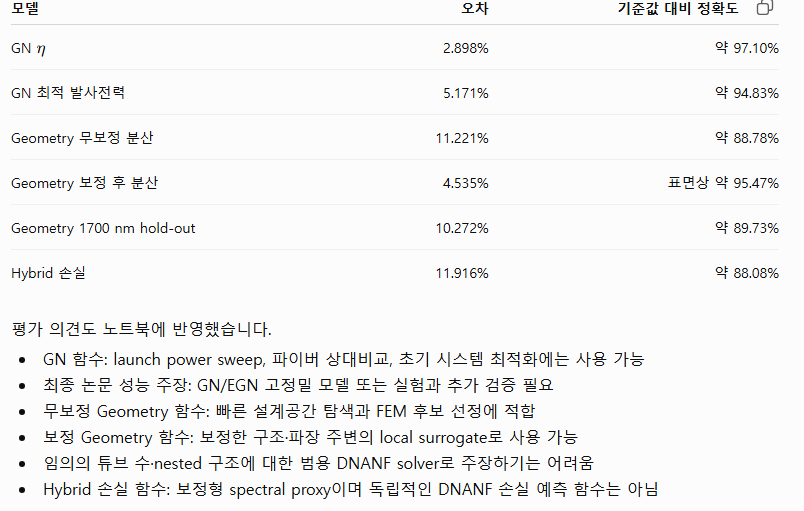

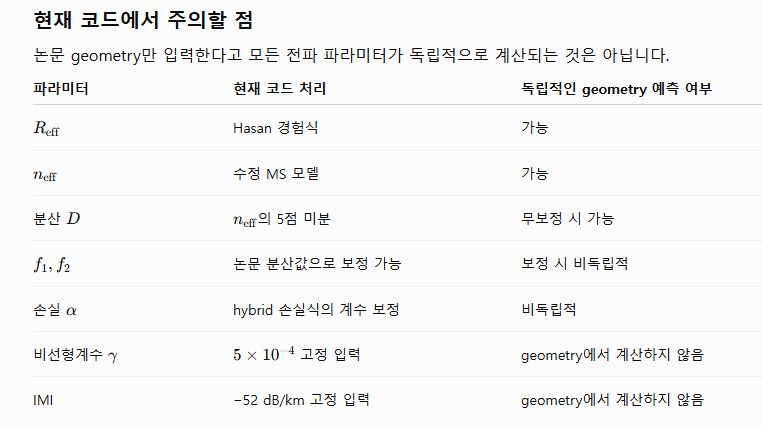

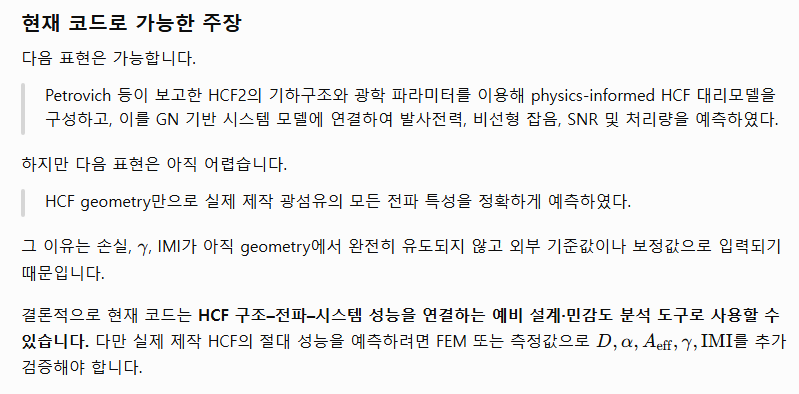